In [2]:
# Install the Kaggle CLI tool (quiet mode, -q) so we can download datasets directly from Kaggle
!pip install -q kaggle

In [3]:
# download the dataset from kaggle
#!/bin/bash
!kaggle datasets download kaku321/citrus-plant-disease

Dataset URL: https://www.kaggle.com/datasets/kaku321/citrus-plant-disease
License(s): CC0-1.0
100% 326M/326M [00:03<00:00, 110MB/s]



In [4]:
import zipfile  # standard library module used to read/extract .zip archive files

In [5]:
with zipfile.ZipFile("citrus-plant-disease.zip","r") as zip_ref:  # open the downloaded zip file in read-only mode
  zip_ref.extractall("dataset")  # extract every file inside the zip into a folder named 'dataset'

image classification using MobileNetV2 - Step 1 Import LIbraries

In [6]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import (
    GlobalAveragePooling2D,
    Dense,
    Dropout,
    BatchNormalization,
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

import seaborn as sns

In [7]:
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.20.0
[]


Step 2 : Explore the Dataset Structure

In [8]:
DATASET_DIR = "dataset"

for root, dirs, files in os.walk(DATASET_DIR):
  level = root.replace(DATASET_DIR, "").count(os.sep)
  indent = " " * 2 * (level)
  print(f"{indent}{os.path.basename(root)}/")
  if level < 2:
    subindent = " " * 2 * (level + 1)
    for f in files[:2]:
      print(f"{subindent}{f}")

dataset/
  Gummosis/
    1631.jpg
    1855.jpg
  Healthy/
    1631.jpg
    1855.jpg
  Canker/
    1631.jpg
    1855.jpg
  Lemon-butterfly/
    1631.jpg
    1855.jpg
  Greening/
    2646.jpg
    3370.jpg
  Leaf-miner/
    1631.jpg
    1855.jpg


In [9]:
class_names = sorted(os.listdir(DATASET_DIR))
print(class_names)

['Canker', 'Greening', 'Gummosis', 'Healthy', 'Leaf-miner', 'Lemon-butterfly']


In [10]:
for cls in class_names:
  print(f"{cls}: {len(os.listdir(os.path.join(DATASET_DIR, cls)))}")

Canker: 2696
Greening: 1750
Gummosis: 2888
Healthy: 5320
Leaf-miner: 3880
Lemon-butterfly: 3152


Step 3 - Data Preprocessing

In [11]:
from random import shuffle
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1.0 /255, #normalize pixel values from [0, 255] to [0,1]
    rotation_range = 25,
    width_shift_range = 0.15,
    height_shift_range = 0.15,
    shear_range = 0.1,
    zoom_range = 0.2,
    validation_split = 0.2,
    horizontal_flip = True,
    fill_mode = "nearest"
)

# validation data generator
val_datagen = ImageDataGenerator(
    rescale=1.0 /255,
    validation_split = 0.2
)

train_generator =  train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode="categorical",
    subset = "training",
    shuffle = True,
    seed=42,
)

val_generator = val_datagen.flow_from_directory(
    DATASET_DIR,
    target_size = IMG_SIZE,
    batch_size = BATCH_SIZE,
    class_mode="categorical",
    subset = "validation",
    shuffle = True,
    seed=42,
)

NUM_CLASSES = train_generator.num_classes
print(f"Number of classes: {NUM_CLASSES}")
print(f"Class indices: {train_generator.class_indices}")

Found 15750 images belonging to 6 classes.
Found 15750 images belonging to 6 classes.
Number of classes: 6
Class indices: {'Canker': 0, 'Greening': 1, 'Gummosis': 2, 'Healthy': 3, 'Leaf-miner': 4, 'Lemon-butterfly': 5}


Step 4 - Visualize a few sample images

Images shape: (32, 224, 224, 3)
Labels shape: (32, 6)


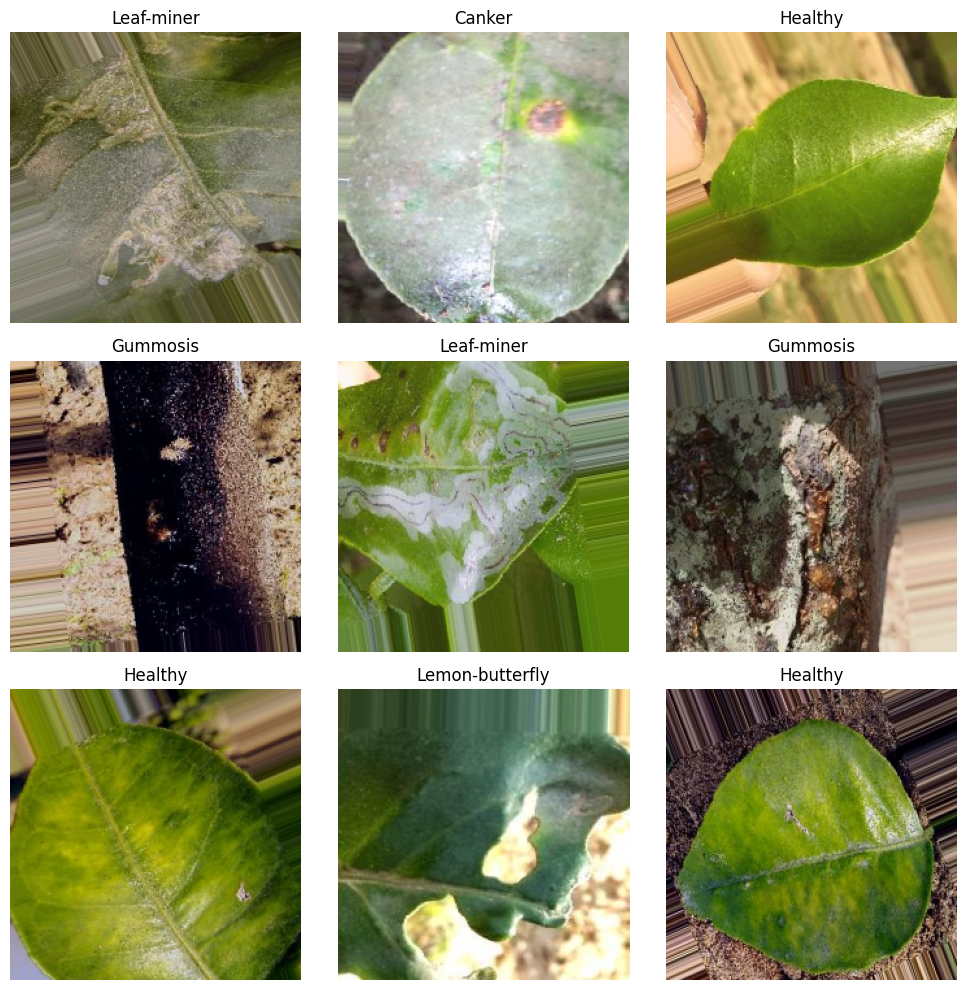

In [12]:
images, labels = next(train_generator)
print(f"Images shape: {images.shape}")
print(f"Labels shape: {labels.shape}")

plt.figure(figsize=(10,10))
class_list = list(train_generator.class_indices.keys())
for i in range(min(9, len(images))):
  plt.subplot(3,3,i+1)
  plt.imshow(images[i])
  label_idx = np.argmax(labels[i])
  plt.title(class_list[label_idx])
  plt.axis("off")
plt.tight_layout()
plt.savefig("sample_images.png")
plt.show()

Step 5 : build the transfer learning model

In [13]:
base_model = MobileNetV2(
    input_shape = (*IMG_SIZE, 3),
    include_top = False,
    weights = "imagenet",
)

base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
x = Dense(128, activation="relu")(x)
output = Dense(NUM_CLASSES, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,427,846 (9.26 MB)

 Trainable params: 167,302 (653.52 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

Step 6 : Compile the model

In [14]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

Step 7 : Set up Callbacks

In [15]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=5, verbose=1),
    ModelCheckpoint("model.h5", monitor="val_loss", save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.1, patience=2, verbose=1),
]

Step 8 : Train the model (Phase 1 - Frozen Base)

In [ ]:
EPOCHS = 20

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=val_generator,
    validation_steps=val_generator.samples // BATCH_SIZE,
    callbacks=callbacks,
)

Epoch 1/20
492/492 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6425 - loss: 0.9924
Epoch 1: val_loss improved from None to 0.15785, saving model to model.h5



Epoch 1: finished saving model to model.h5
492/492 ━━━━━━━━━━━━━━━━━━━━ 1388s 3s/step - accuracy: 0.7934 - loss: 0.5721 - val_accuracy: 0.9485 - val_loss: 0.1579 - learning_rate: 1.0000e-04
Epoch 2/20
  1/492 ━━━━━━━━━━━━━━━━━━━━ 8:30 1s/step - accuracy: 1.0000 - loss: 0.0904

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss improved from 0.15785 to 0.15751, saving model to model.h5



Epoch 2: finished saving model to model.h5
492/492 ━━━━━━━━━━━━━━━━━━━━ 617s 1s/step - accuracy: 1.0000 - loss: 0.0904 - val_accuracy: 0.9488 - val_loss: 0.1575 - learning_rate: 1.0000e-04
Epoch 3/20
492/492 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9176 - loss: 0.2300
Epoch 3: val_loss improved from 0.15751 to 0.08769, saving model to model.h5



Epoch 3: finished saving model to model.h5
492/492 ━━━━━━━━━━━━━━━━━━━━ 1399s 3s/step - accuracy: 0.9250 - loss: 0.2077 - val_accuracy: 0.9769 - val_loss: 0.0877 - learning_rate: 1.0000e-04
Epoch 4/20
  1/492 ━━━━━━━━━━━━━━━━━━━━ 8:44 1s/step - accuracy: 0.9688 - loss: 0.1816
Epoch 4: val_loss improved from 0.08769 to 0.08718, saving model to model.h5



Epoch 4: finished saving model to model.h5
492/492 ━━━━━━━━━━━━━━━━━━━━ 609s 1s/step - accuracy: 0.9688 - loss: 0.1816 - val_accuracy: 0.9773 - val_loss: 0.0872 - learning_rate: 1.0000e-04
Epoch 5/20
352/492 ━━━━━━━━━━━━━━━━━━━━ 3:34 2s/step - accuracy: 0.9436 - loss: 0.1633

Step 9 : Fine Tuning ( phase 2 - unfreezing top layers)

In [ ]:
base_model.trainable = True

for layer in base_model.layers[:100]:
  layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=0.00001),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

fine_tune_epochs = 10
total_epochs = EPOCHS + fine_tune_epochs

history_fine_tune = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    validation_data=val_generator,
    epochs=fine_tune_epochs,
    callbacks=callbacks,
    )

Step 10 : Plot Training History

In [ ]:
def plot_training_history(hist1, hist2=None):
  acc = hist1.history['accuracy']
  val_acc = hist1.history['val_accuracy']
  loss = hist1.history['loss']
  val_loss = hist1.history['val_loss']

  if hist2 is not None:
    acc += hist2.history['accuracy']
    val_acc += hist2.history['val_accuracy']
    loss += hist2.history['loss']
    val_loss += hist2.history['val_loss']

  epochs_range = range(len(acc))
  plt.figure(figsize=(12, 4))
  plt.subplot(1, 2, 1)
  plt.plot(epochs_range, acc, label='Training Accuracy')
  plt.plot(epochs_range, val_acc, label='Validation Accuracy')
  plt.legend(loc='lower right')
  plt.title('Training and Validation Accuracy')

  plt.subplot(1, 2, 2)
  plt.plot(epochs_range, loss, label='Training Loss')
  plt.plot(epochs_range, val_loss, label='Validation Loss')
  plt.legend(loc='upper right')
  plt.title('Training and Validation Loss')
  plt.show()

plot_training_history(history, history_fine_tune)

Step 11 : Evaluate Model

In [ ]:
val_generator.reset()
y_pred_probs = model.predict(val_generator, steps=val_generator.samples // BATCH_SIZE)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_generator.classes

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_list))

print("Confusion Matrix")
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

Step 12: Save the model

In [ ]:
model.save("citrus_disease_mobilenetv2_final.h5")
print("model saved as citrus_disease_mobilenetv2_final.h5")

model.save("citrus_disease_mobilenetv2_final.keras")
print("model saved as citrus_disease_mobilenetv2_final.keras")

step 13 : Test Model on a single Image

In [ ]:
from tensorflow.keras.preprocessing import image as keras_image

def predict_single_image(img_path, model, class_list, image_size=(224, 224)):
  img = keras_image.load_img(img_path, target_size=image_size)
  img_array = keras_image.img_to_array(img)
  img_array = np.expand_dims(img_array, axis=0)
  img_array /= 255.0

  predictions = model.predict(img_array)
  predicted_index = np.argmax(predictions[0])
  predicted_class = class_list[predicted_index]
  confidence = float(np.max(predictions[0])) * 100

  print(f"Predicted class: {predicted_class}")
  print(f"Confidence: {confidence:.2f}%")

  img = plt.imread(img_path)
  plt.imshow(img)
  plt.axis("off")
  plt.title(f"Predicted: {predicted_class}")
  plt.show()

  return predicted_class

predict_single_image("/content/dataset/Leaf-miner/1.jpg")

Step 14 : Interactive chose file button

In [ ]:
import io
from PIL  import Image

try:
  import ipywidgets as widgets
  from IPython.display import display, clear_output

  upload_button = widgets.FileUpload(
      accept="image/*",
      multiple=False,
      description="Upload Image",
  )

  output_area = widgets.Output()
  display(upload_button, output_area)

  def _on_upload_change(change):
    with output_area:
      clear_output()

      if not upload_button.value:
        return

      value = upload_button.value
      if isinstance(value, dict):
          # ipywidgets 7.x: value is a dict keyed by filename
          file_info = list(value.values())[0]
          file_name = file_info["metadata"]["name"]
          file_bytes = file_info["content"]
      else:
          # ipywidgets 8.x: value is a tuple of dicts
          file_info = value[0]
          file_name = file_info["name"]
          file_bytes = file_info["content"]

      img = Image.open(io.BytesIO(file_bytes)).convert("RGB")
      img_resized = img.resize(IMG_SIZE)
      img_array = np.array(img_resized)/255.0
      img_array = np.expand_dims(img_array, axis=0)

      predictions = model.predict(img_array)
      predicted_index = np.argmax(predictions[0])
      predicted_class = class_list[predicted_index]
      confidence = float(np.max(predictions[0])) * 100

      print(f"Predicted class: {predicted_class}")
      print(f"Confidence: {confidence:.2f}%")

      plt.imshow(img)
      plt.axis("off")
      plt.title(f"Predicted: {predicted_class}")
      plt.show()

  upload_button.observe(_on_upload_change, names="value")
  print("Click the button below to choose a leaf image and get an instant prediction:")
  display(upload_button, output_area)

except ImportError:
    # Fallback for Google Colab, which has its own native upload dialog
    print("ipywidgets not available — falling back to Colab's native file picker.")

    def choose_file_colab():
        """
        Opens Colab's built-in 'Choose Files' upload dialog, then runs the same
        prediction pipeline on whichever image file is selected.
        """
        from google.colab import files  # only importable inside Google Colab

        uploaded = files.upload()  # opens a native "Choose Files" browser dialog
        for file_name, file_bytes in uploaded.items():
            img = Image.open(io.BytesIO(file_bytes)).convert("RGB")
            img_resized = img.resize(IMG_SIZE)
            img_array = np.array(img_resized) / 255.0
            img_array = np.expand_dims(img_array, axis=0)

            predictions = model.predict(img_array)
            predicted_index = np.argmax(predictions[0])
            predicted_class = class_list[predicted_index]
            confidence = float(np.max(predictions[0])) * 100

            print(f"File: {file_name}")
            print(f"Predicted class: {predicted_class} ({confidence:.2f}% confidence)")

            plt.imshow(img_resized)
            plt.title(f"{predicted_class} ({confidence:.2f}%)")
            plt.axis("off")
            plt.show()

    # Uncomment the line below to trigger the Colab "Choose Files" dialog:
    # choose_file_colab()

Step 15 : Deploy an Interactive Gradio UI

In [ ]:
# Install Gradio (quiet mode). Skip this cell if already installed.
!pip install -q gradio


In [ ]:
import gradio as gr
import numpy as np

# Reuse the same class_list / IMG_SIZE / model that were used earlier in the notebook.
# If you're running this section on its own (fresh runtime), load the saved model first:
#   from tensorflow.keras.models import load_model
#   model = load_model("citrus_disease_mobilenetv2_final.keras")
#   class_list = sorted(os.listdir(DATASET_DIR))  # must match the training class order

def predict_leaf_disease(img):
    """
    Takes a PIL/numpy image from the Gradio Image component, runs it through
    the trained MobileNetV2 model, and returns a class -> probability dict
    that Gradio's Label component can render as a bar chart.
    """
    if img is None:
        return {}

    # gr.Image(type="pil") gives a PIL.Image; make sure it's RGB and the right size
    img = img.convert("RGB").resize(IMG_SIZE)
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)[0]

    # Return a probability for every class so gr.Label can show the full ranking
    return {class_list[i]: float(predictions[i]) for i in range(len(class_list))}


demo = gr.Interface(
    fn=predict_leaf_disease,
    inputs=gr.Image(type="pil", label="Upload a citrus leaf image"),
    outputs=gr.Label(num_top_classes=len(class_list), label="Prediction"),
    title="Citrus Plant Disease Classifier",
    description=(
        "Upload a photo of a citrus leaf and the MobileNetV2 transfer-learning "
        "model will predict the disease class along with its confidence."
    ),
    examples=None,  # optionally pass a list of sample image paths here, e.g. ["dataset/Leaf-miner/1.jpg"]
    flagging_mode="never",
)

# share=True gives you a public URL (useful in Colab); set to False for local-only.
demo.launch(share=True, debug=False)
